# Learning goals
After today's lesson you should be able to:
- Understand the differences between SLX, spatial lag and spatial error models
- Identify when to use different kinds of models
- Implement all three types of models in pysal
- Check our model outcomes 

This week's lesson is a simplied version of:  
- The [Week 11 on Spatial Regression the Geographic Data Science book](https://geographicdata.science/book/notebooks/11_regression.html)


In [16]:
from pysal.lib import weights
from pysal.explore import esda
import numpy
import pandas
import geopandas
import matplotlib.pyplot as plt
import seaborn
import contextily as ctx
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

## 0. Data: San Diego Airbnb

We'll examine information about Airbnb properties in San Diego, CA to learn about how regression works. 
This dataset contains house intrinsic characteristics, both continuous (number of beds as in `beds`) and categorical (type of renting or, in Airbnb jargon, property group as in the series of `pg_X` binary variables), but also variables that explicitly refer to the location and spatial configuration of the dataset (e.g., distance to Balboa Park, `d2balboa` or neighborhood id, `neighborhood_cleansed`).

Also, note that there is a great notebook in the Geographic Data Science book on [how this dataset was cleaned](https://geographicdata.science/book/data/airbnb/regression_cleaning.html). It has some example code for: 
- How to calculate the driving distance to a certain location (Balboa Park in this example) using a free API called Nomatim, since we only learned about the Google Maps API. 
- How to get the elevation of a location
- How to categorize neighborhoods (here, by size and whether they are coastal).
- Creating dummy variables

Let us first load the dataset:

In [3]:
# load the dataset: 
db = geopandas.read_file("https://www.dropbox.com/s/zkucu7jf1xug869/regression_db.geojson?dl=1")

# db['pool'] = db['pool'].astype(int)
# db['coastal'] = db['coastal'].astype(int)
# db['pg_Apartment'] = db['pg_Apartment'].astype(int)
# db['pg_Condominium'] = db['pg_Condominium'].astype(int)
# db['pg_House'] = db['pg_House'].astype(int)
# db['pg_Other'] = db['pg_Other'].astype(int)
# db['pg_Townhouse'] = db['pg_Townhouse'].astype(int)
# db['rt_Entire_home/apt'] = db['rt_Entire_home/apt'].astype(int)
# db['rt_Private_room'] = db['rt_Private_room'].astype(int)
# db['rt_Shared_room'] = db['rt_Shared_room'].astype(int)

Notice here that we have: 
- **Discrete variables** (number of bedrooms, beds, baths)
- **Dummy variables** (whether there is a pool, whether near the coast, room type)

**Remember that for dummy variables we always run the regression leaving out one category as our baseline.**

In [4]:
# check the dataset .head()
db.head()

# db.shape
# db.info()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (-117.12971 32.75399)
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (-117.25253 32.78421)
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (-117.14121 32.75327)
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (-117.15269 32.93110)
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (-117.21870 32.74202)


These are the explanatory variables we will use throughout this lab.

In [6]:
variable_names = [
    "accommodates",  # Number of people it accommodates
    "bathrooms",  # Number of bathrooms
    "bedrooms",  # Number of bedrooms
    "beds",  # Number of beds
    # Below are binary variables, 1 True, 0 False
    "rt_Private_room",  # Room type: private room
    "rt_Shared_room",  # Room type: shared room
    "pg_Condominium",  # Property group: condo
    "pg_House",  # Property group: house
    "pg_Other",  # Property group: other
    "pg_Townhouse",  # Property group: townhouse
]

We want to explore the factors that influence nightly rental housing prices. As a first step, let's plot our dependent variable to examine its distribution and check for any potential spatial dependence patterns.

(-117.29746305564564,
 -116.93902101960468,
 32.54800602624714,
 33.10858837723677)

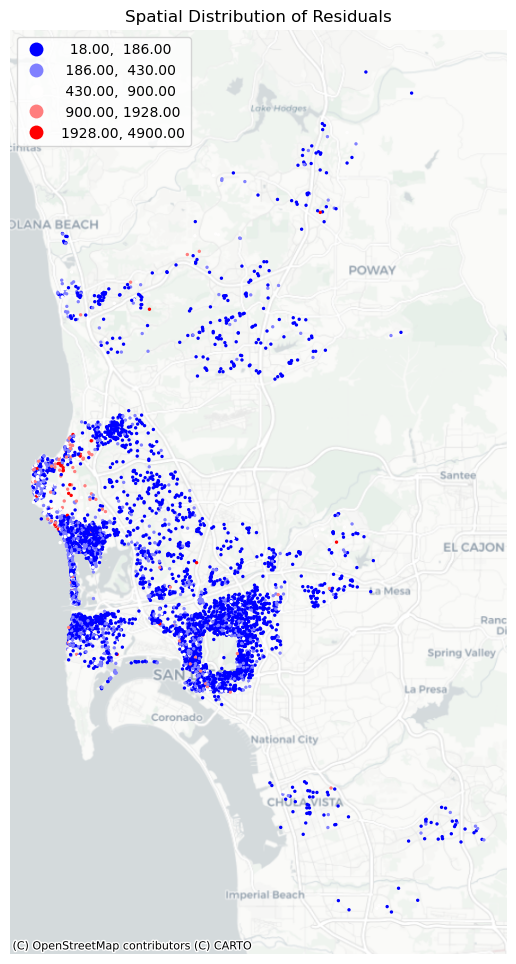

In [7]:
# Create subplots with a 1x2 layout
fig, axes = plt.subplots(1, 1, figsize=(12, 12))

# Plot the full map of residuals
db.plot(column="price", cmap="bwr", legend=True, alpha=1, markersize=2, scheme = "naturalbreaks", ax=axes)
ctx.add_basemap(axes, crs=db.crs, source=ctx.providers.CartoDB.Positron)
axes.set_title("Spatial Distribution of Residuals")
axes.axis("off")


# 1. Non-spatial regression, a refresh
For example, in our case, we may want to express the price of a house as a function of the number of bedrooms it has and whether it is a condominium or not. At the individual level, we can express this as:

$$
log(P_i) = \alpha + \sum_k \mathbf{X}_{ik}\beta_k  + \epsilon_i
$$

where 
- $P_i$ is the Airbnb price of house $i$,
- $X$ is a set of covariates that we use to explain such price (e.g., No. of bedrooms and condominium binary variable).
- $\beta$ is a vector of parameters that give us information about in which way and to what extent each variable is related to the price, and
- $\alpha$, the constant term, is the average house price when all the other variables are zero.
- The term $\epsilon_i$ is usually referred to as "error" and captures elements that influence the price of a house but are not included in $X$.

**We also take the *log of prices* often since a log scale allows us a better understanding of the percentage change instead of the absolute dollar change.**

We can also express this relation in matrix form, excluding sub-indices for $i$, which yields:

$$
log(P) = \alpha + \mathbf{X}\beta + \epsilon
$$

## 1.1 Building up the OLS model

Practically speaking, linear regressions in Python are rather streamlined and easy to work with. There are also several packages which will run them (e.g., `statsmodels`, `scikit-learn`, `pysal`). We will import the `spreg` module in Pysal:

In [8]:
from pysal.model import spreg

In the context of this lab, it makes sense to start with `spreg`, as that is the only library that will allow us to move into explicitly spatial econometric models. To fit the model specified in the equation above with $X$ as the list defined, using ordinary least squares (OLS), we only need the following line of code:

In [9]:
# Fit OLS model
m1 = spreg.OLS(
    
    # Dependent variable
    # convert to array using .values
    db[["log_price"]].values,
    
    # Independent variables
    db[variable_names].values,
    
    # Dependent variable name
    name_y="log_price",
    
    # Independent variable name
    name_x=variable_names,
    
)

In the above code, we use the command `OLS`, part of the `spreg` sub-package, and specify the dependent variable (the log of the price, so we can interpret results in terms of percentage change) and the explanatory ones. Note that both objects need to be arrays, so we extract them from the `pandas.DataFrame` object using `.values`.

In order to inspect the results of the model, we can print the `summary` attribute:

In [21]:
# check out the model results and model diagnostics
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          11
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6099
R-squared           :      0.6683
Adjusted R-squared  :      0.6678
Sum squared residual:     1320.15                F-statistic           :   1229.0564
Sigma-square        :       0.216                Prob(F-statistic)     :           0
S.E. of regression  :       0.465                Log likelihood        :   -3988.895
Sigma-square ML     :       0.216                Akaike info criterion :    7999.790
S.E of regression ML:      0.4648                Schwarz criterion     :    8073.685

------------------------------------------------------------

### Results are largely as expected: 
- houses tend to be significantly more expensive if they accommodate more people (`accommodates`), if they have more bathrooms and bedrooms, and if they are a condominium or part of the "other" category of house type.
- Conversely, given a number of rooms, houses with more beds (i.e., listings that are more "crowded") tend to go for cheaper, as it is the case for properties where one does not rent the entire house but only a room (`rt_Private_room`) or even shares it (`rt_Shared_room`). Of course, you might conceptually doubt the assumption that it is possible to *arbitrarily* change the number of beds within an Airbnb without eventually changing the number of people it accommodates, but methods to address these concerns using *interaction effects* won't be discussed here. 

### Model diagnostics and Hidden structures

In general, our model performs well, being able to predict slightly about two-thirds ($R^2=0.67$) of the variation in the mean nightly price using the covariates we've discussed above.

Let us look at other metrics of model performance: 

- **The Multicollinearity Condition Number (MCN)** is a measure used to detect overall multicollinearity: A number below 10 indicates low multicollinearity; independent variables are not highly correlated. A number between 10 and 30 suggests moderate multicollinearity, which might cause some instability in coefficient estimates. A number above 30 suggests severe multicollinearity, meaning that some independent variables are almost collinear. Here, 11.964 is relatively low, suggesting multicollinearity is not a major concern.


- **Test on Normality of Errors using Jarque-Bera Test**: The Jarque-Bera test checks whether the residuals are normally distributed. A p-value of 0.0000 suggests the residuals deviate significantly from normality.

- **Diagnostics for Heteroskedasticity uisng Breusch-Pagan Test and Koenker-Bassett Test**:
Both tests examine heteroskedasticity, which occurs when residual variance is not constant across observations.
The p-values of 0.0000 indicate strong evidence of heteroskedasticity.
This suggests that the model may have non-constant variance in the errors, potentially leading to inefficient OLS estimates.





## 1.2 Checking the structure of error term

Let us further look at the error term.
One simple concept might be to look at is the correlation between the error in predicting an Airbnb and the error in predicting its nearest neighbor. If spatial patterns (e.g., **spatial autocorrelation**) exist in our residuals, this could indicate a missing spatial component in our model, in other words, **ommitted variable bias**. 

Next, within the scope of non-spatial regression, we will do the following to check the issues within our models and try to improve the model performance:
- Objective 1: Examine whether spatial dependence exists in our residuals. This is the case that many of the most over- and under-predicted obs are near one another in the city, it may also be the case that there is some sort of *contagion* or spatial spillovers in the nightly rent price. This often is apparent when individuals seek to price their Airbnb listings to compete with similar nearby listings. Since our model is not aware of this behavior, its errors may tend to cluster.
- Objective 2: Identify and incorporate potential omitted variables to account for unobserved factors influencing nightly rent prices. 

### 1.2.1 Objective 1: identify spatial dependence

Let us now focus on our first objective. to achieve this, we will (1) Visualize residuals on a map to detect any clustering patterns, (2) Calculate Moran’s I to quantify spatial autocorrelation, as covered in last week's session.

The following code plot the residuals based on the current nightly (log) Airbnb price model and zoom into the San Diego Downtown.

Note here that `m1.u` are the residuals from the model `m1`. 

In [22]:
# Create column with residual values from m1
db["residual"] = m1.u

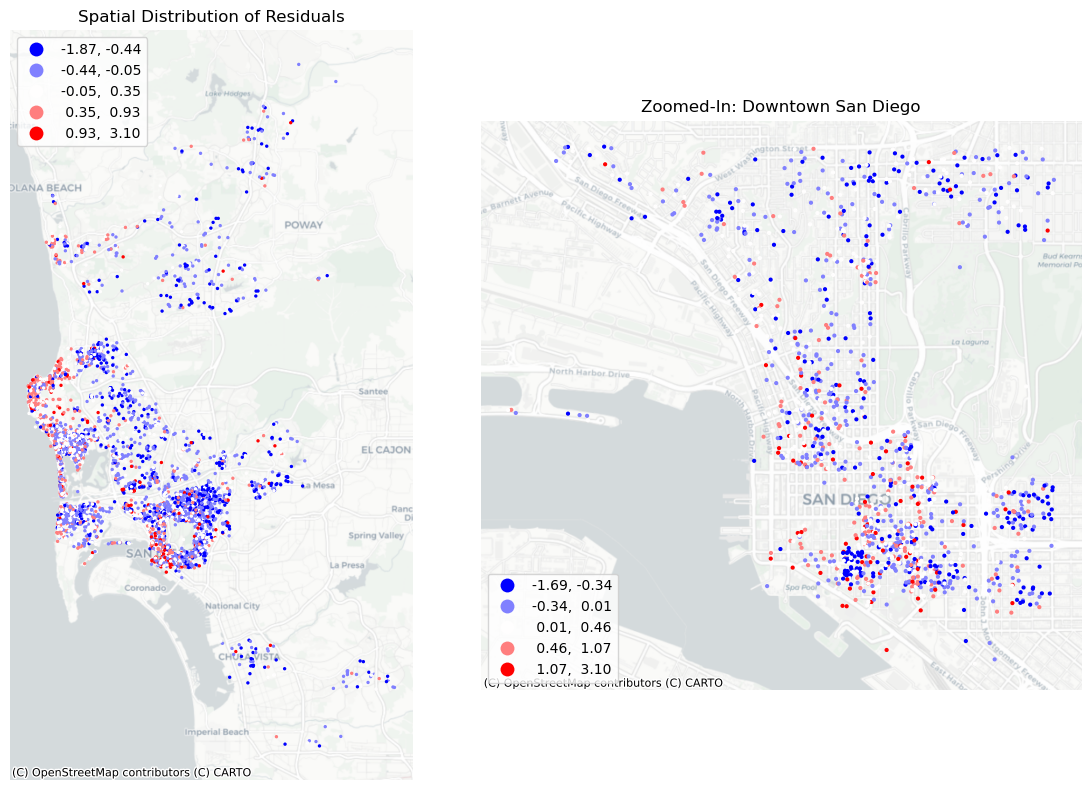

In [23]:
# Create subplots with a 1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Plot the full map of residuals
db.plot(column="residual", cmap="bwr", legend=True, alpha=1, markersize=2, scheme = "naturalbreaks", ax=axes[0])
ctx.add_basemap(axes[0], crs=db.crs, source=ctx.providers.CartoDB.Positron)
axes[0].set_title("Spatial Distribution of Residuals")
axes[0].axis("off")


# Define the bounding box for downtown San Diego (approximate coordinates)
downtown_bounds = db.cx[-117.2:-117.14, 32.7:32.75]
# Plot the zoomed-in downtown residuals
downtown_bounds.plot(column="residual", cmap="bwr", legend=True, alpha=1, markersize=4, scheme = "naturalbreaks", ax=axes[1])
ctx.add_basemap(axes[1], crs=db.crs, source=ctx.providers.CartoDB.Positron)
axes[1].set_title("Zoomed-In: Downtown San Diego")
axes[1].axis("off")

# Show the figure
plt.tight_layout()
plt.show()

Based on the residual maps, we can identify specific areas where clustering patterns emerge
- La Jolla: A high-end coastal neighborhood where residuals may indicate systematic underestimation of prices due to unmodeled location desirability.
- Pacific Beach & Mission Beach: Clusters of high residuals (red) suggest that Airbnb prices might be higher than the model predicts, possibly due to seasonal demand and proximity to the ocean.
- Southeastern San Diego & National City: Clusters of negative residuals (blue) suggest potential overestimation of prices in less touristy areas.


Next, we will use *spatial weights* and *global Morna'I* to represent the geographic relationships between observations. For this example, we'll start off with a $KNN$ matrix where $k=1$, meaning we're focusing only on the linkages of each Airbnb to their closest other listing.

In [24]:
# constrcut the knn spatial weight with k = 1
w_knn = weights.KNN.from_dataframe(db, k=1)

# Calculate the Moran's I based on esda function
w_knn.transform = "R"
moran = esda.moran.Moran(db["residual"], w_knn)

0.17510386905787068
0.001


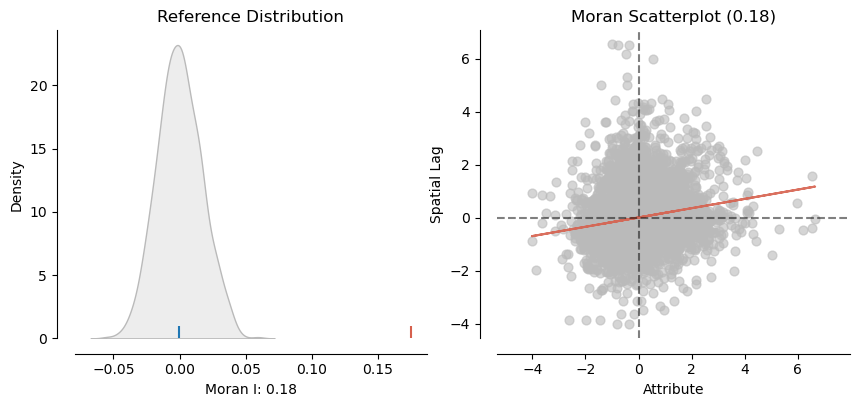

In [25]:
# Get the global Moran's I index
print(moran.I)

# get the significance level
print(moran.p_sim)

# Moran's I plot for spatial autocorrelation
from splot.esda import plot_moran
plot_moran(moran);

In Figure above, we see that our prediction errors tend to cluster!
Above, we show the relationship between our prediction error at each site and the prediction error at the site nearest to it. 
Here, we're using this nearest site to stand in for the *surroundings* of that Airbnb. 
This means that, when the model tends to over-predict a given Airbnb's nightly log price, sites around that Airbnb are more likely to *also be over-predicted*. 

Let's look at the stable $k=20$ number of neighbors.
Examining the relationship between this stable *surrounding* average and the focal Airbnb, we can even find clusters in our model error. 
Recalling the *local Moran* statistics in Week8, Figure below is generated from the code below to identify certain areas where our predictions of the nightly (log) Airbnb price tend to be significantly off:

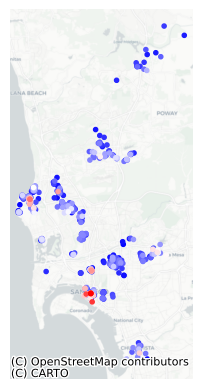

In [26]:
# Re-weight W to 20 nearest neighbors
knn = weights.KNN.from_dataframe(db, k=20)# Row standardize weights
knn.transform = "R"

# Run LISA on residuals
outliers = esda.moran.Moran_Local(m1.u, knn, permutations=9999)

# Select only LISA cluster cores: 
# True:  HH and LL clusters, 
# False: LH and HL outliers.
error_clusters = outliers.q % 2 == 1

# Filter out non-significant clusters
error_clusters &= outliers.p_sim <= 0.001
# error_clusters = (outliers.q % 2 == 1) & (outliers.p_sim <= 0.001)

# Add `error_clusters` and `local_I` columns
ax = (
    db.assign(
        error_clusters=error_clusters,
        local_I=outliers.Is
        # Retain error clusters only
    )
    .query(
        "error_clusters"
        # Sort by I value to largest plot on top
    )
    .sort_values(
        "local_I"
        # Plot I values
    )
    .plot("local_I", cmap="bwr", marker=".")
)

# Add basemap
ctx.add_basemap(ax, crs=db.crs, source=ctx.providers.CartoDB.Positron)
# Remove axes
ax.set_axis_off();

Thus, these areas tend to be locations where our model significantly over/under-predicts the nightly Airbnb price both for that specific observation and observations in its immediate surroundings. 
This is critical since, if we can identify how these areas are structured &mdash; if they have a *consistent geography* that we can model &mdash; then we might make our predictions even better, or at least not systematically mis-predict prices in some areas while correctly predicting prices in other areas. Since significant under- and over-predictions do appear to cluster in a highly structured way, we might be able to use a better model to fix the geography of our model errors. 


### 1.2.2 Objective 2: Checking omitted variables

#### Omitted vairable: Beach and no beach
we first might want to split our data up by regions and see if we’ve got some spatial structure in our residuals. One reasonable theory might be that our model does not include any information about beaches, a critical aspect of why people live and vacation in San Diego. Therefore, we might want to see whether or not our errors are higher or lower depending on whether or not an Airbnb is in a “beach” neighborhood, a neighborhood near the ocean. We use the code below to generate Figure below, which looks at prices between the two groups of houses, “beach” and “no beach”.

Note here that `m1.u` are the residuals from the model `m1`. 

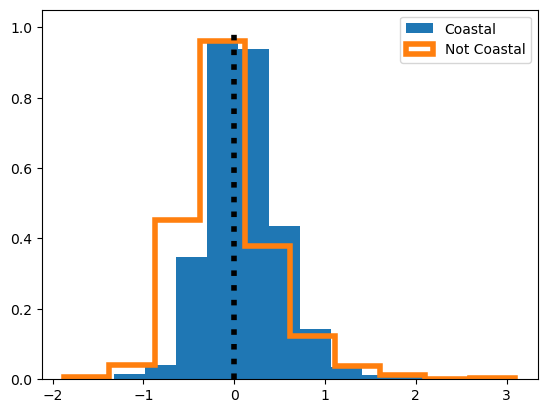

In [27]:
# Create a Boolean (True/False) with whether a
# property is coastal or not
is_coastal = db.coastal.astype(bool)

# Split residuals (m1.u) between coastal and not
coastal = m1.u[is_coastal]
not_coastal = m1.u[~is_coastal]

# Create histogram of the distribution of coastal residuals
plt.hist(
    coastal,    
    density=True, 
    label="Coastal"    
)

# Create histogram of the distribution of non-coastal residuals
plt.hist(
    not_coastal,
    histtype="step",
    density=True,
    linewidth=4,
    label="Not Coastal",
)

# Add Line on 0, 
# 0 → The x-coordinate where the vertical line is drawn.
# 0, 1 → The y-range for the line (from y=0 to y=1).
plt.vlines(0, 0, 1, linestyle=":", color="k", linewidth=4)

# Add legend
plt.legend()

# Display
plt.show()

While it appears that the neighborhoods on the coast have only slightly higher average errors (and have lower variance in their prediction errors), the two distributions are significantly distinct from one another when compared using a classic $t$-test:

In [28]:
# Import the t-test function from SciPy
from scipy.stats import ttest_ind

# Perform a two-sample t-test to compare the means of residuals 
# between coastal and non-coastal properties
ttest_ind(coastal, not_coastal)

# t_statistic: t-value
# p_value: The probability of observing the difference under H0 (equal means)

TtestResult(statistic=array([13.98193858]), pvalue=array([9.442438e-44]), df=array([6108.]))

#### Omitted vairable: neighborhoods

Some neighborhoods may be more desirable than others due to factors not captured in the model, such as local preferences or marketing effects. For example, despite being near the sea, areas like Camp Pendleton—a Marine base—might be less desirable due to noise and pollution. To explore this, we can analyze the distribution of model residuals within each neighborhood.

To make this more clear, we'll first sort the data by the median residual in that neighborhood, and then make a boxplot, which shows the distribution of residuals in each neighborhood:

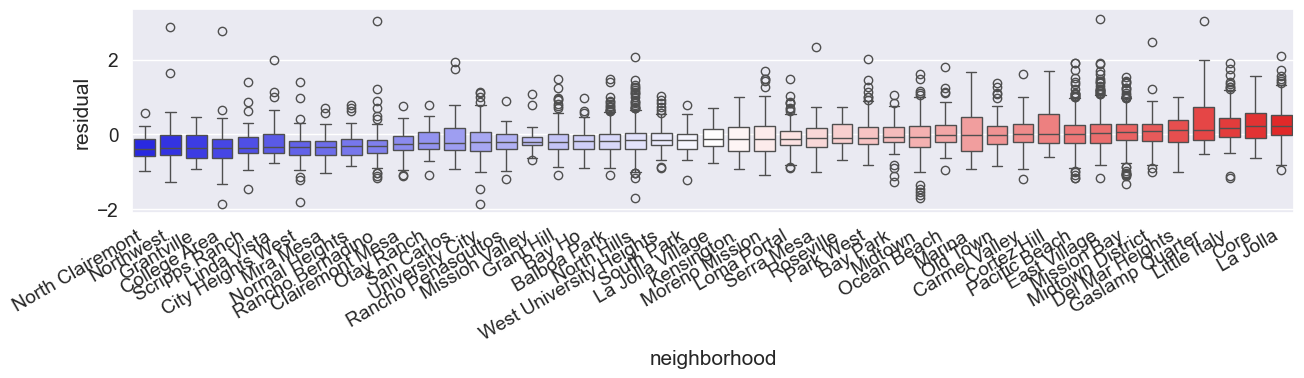

In [29]:
# Create column with residual values from m1
db["residual"] = m1.u

# Obtain the median value of residuals in each neighborhood
medians = (
    db.groupby("neighborhood")
    .residual.median()
    .to_frame("hood_residual")
)

# Increase fontsize
seaborn.set(font_scale=1.25)
# Set up figure
f = plt.figure(figsize=(15, 3))
# Grab Current Axes
ax = plt.gca()

# Generate bloxplot of values by neighborhood
# Note the data includes the median values merged on-the-fly
seaborn.boxplot(
    data=db.merge(
        medians, how="left", left_on="neighborhood", right_index=True
    ).sort_values("hood_residual"),
    x="neighborhood",
    y="residual",
    ax=ax,
    palette="bwr",
)
# Auto-format of the X labels
f.autofmt_xdate()
# Display
plt.show()

No neighborhood is completely separate, but some, like Gaslamp Quarter, Little Italy, and The Core, stand out. This suggests that intangible factors, such as neighborhood popularity, may influence the model. Also, Noting that many of the most over- and under-predicted neighborhoods are near one another in the city. This echos the spatial dependence pattern we find in the Section 1.2 where there is some sort of *contagion* or spatial spillovers in the nightly rent price that suggest individuals seek to price their Airbnb listings to compete with similar nearby listings.


#### Omitted vairable: distance to the Balboa Park

One relevant proximity-driven variable that could influence our San Diego model is based on the listings proximity to Balboa Park. A common tourist destination, Balboa Park is a central recreation hub for the city of San Diego, containing many museums and the San Diego Zoo. Thus, it could be the case that people searching for Airbnbs in San Diego are willing to pay a premium to live closer to the park. If this were true *and* we omitted this from our model, we may indeed see a significant spatial pattern caused by this distance decay effect. 

Therefore, this is sometimes called a *spatially patterned omitted covariate*: geographic information our model needs to make good predictions which we have left out of our model. Therefore, let's build a new model containing this distance to Balboa Park covariate. First, though, it helps to visualize the structure of this distance covariate itself:

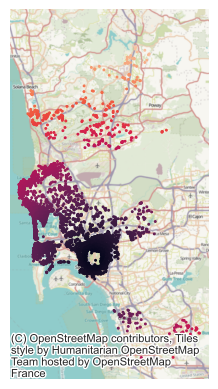

In [31]:
ax = db.plot("d2balboa", marker=".", s=5)
ctx.add_basemap(ax, crs=db.crs, )
ax.set_axis_off();

## 1.3 Adding Omitted Variables

Now, let's check for potential omitted variables by incorporating them into our regression model and evaluating whether the models perform better.

To run a linear model that includes an additional binary variable indicating whether the house/condo is located near the coast, we add this variable to the list of originally included variables, and name the new model m2:

In [32]:
# Run model 2 adding coastal variable
coastal_names = variable_names + ["coastal"]

m2 = spreg.OLS(
    db[["log_price"]].values,
    db[coastal_names].values,
    name_y="log_price",
    name_x=coastal_names,
)

print(m2.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          12
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6098
R-squared           :      0.6796
Adjusted R-squared  :      0.6791
Sum squared residual:      1275.2                F-statistic           :   1176.0582
Sigma-square        :       0.209                Prob(F-statistic)     :           0
S.E. of regression  :       0.457                Log likelihood        :   -3883.066
Sigma-square ML     :       0.209                Akaike info criterion :    7790.133
S.E of regression ML:      0.4568                Schwarz criterion     :    7870.745

------------------------------------------------------------

The results suggest that being located in a coastal area increases the nightly rental housing price by approximately 18.5%, which aligns with our expectations. This indicates that proximity to the coast is a desirable feature that contributes to higher rental prices.

We stepwisely add another omitted variable, distance to Balboa Park, and name the new model m3.

In [34]:
# Run model 3 adding distance to balboa
balboa_names = coastal_names + ["d2balboa"]

m3 = spreg.OLS(
    db[["log_price"]].values,
    db[balboa_names].values,
    name_y="log_price",
    name_x=balboa_names,
)

print(m3.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          13
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6097
R-squared           :      0.6809
Adjusted R-squared  :      0.6803
Sum squared residual:     1269.98                F-statistic           :   1084.3883
Sigma-square        :       0.208                Prob(F-statistic)     :           0
S.E. of regression  :       0.456                Log likelihood        :   -3870.549
Sigma-square ML     :       0.208                Akaike info criterion :    7767.097
S.E of regression ML:      0.4559                Schwarz criterion     :    7854.427

------------------------------------------------------------

As the result indicate, the distance to Balboa Park variable does not fit our theory about how distance to amenity should affect the price of an Airbnb; the coefficient estimate is *positive*, meaning that people are paying a premium to be *further* from Balboa Park. We will revisit this result later on.

When you inspect the regression diagnostics and output, you see that this covariate is not quite as helpful as we might anticipate:

In [35]:
pd.DataFrame(
    [
        [m1.r2, m1.ar2, m1.f_stat[0], m1.jarque_bera["jb"], m1.breusch_pagan["bp"], m1.koenker_bassett["kb"]],
        [m2.r2, m2.ar2, m2.f_stat[0], m2.jarque_bera["jb"], m2.breusch_pagan["bp"], m2.koenker_bassett["kb"]],
        [m3.r2, m3.ar2, m3.f_stat[0], m3.jarque_bera["jb"], m3.breusch_pagan["bp"], m3.koenker_bassett["kb"]],
    ],
    index=["M1", "M2", "M3"],  # Model names
    columns=["R²", "Adj. R²", "F-statistic", "Jarque-Bera", "Breusch-Pagan", "Koenker-Bassett"],  # Column names
)

,R²,Adj. R²,F-statistic,Jarque-Bera,Breusch-Pagan,Koenker-Bassett
M1,0.668345,0.667801,1229.056400,2671.610742,322.532346,135.581155
M2,0.679637,0.679059,1176.058196,3753.876936,428.408594,162.339508
M3,0.680947,0.680319,1084.388290,3796.799877,438.845186,165.570828


FOr easier comparison, we will create a regression summary table where each column corresponds to a different model by using `statsmodels` or `spreg` along with `pandas`. Below is the code that stepwise adds the three vairables we examined to the OLS model and presents the results in a single summary table:

In [37]:
import statsmodels.api as sm   # import statsmodels library
from statsmodels.iolib.summary2 import summary_col  # For formatted tables

# create a variable in the dataframe named "const" with all values equal to 1
db['CONST'] = 1

# Define independent variable sets for stepwise regression
variables_model1 = ['CONST'] + variable_names
variables_model2 = variables_model1  + ["coastal"]
variables_model3 = variables_model2 + ["d2balboa"]

# define a list save results
result_list = []

for m in range(1,4):  # generate value from 1 to 4

    # define dependent variable y
    y = db['log_price']

    # define independent variable X 
    X = db[eval('variables_model' + str(m))]       # eval() function is used to loop over variable names

    # define regression model 
    reg_ols = sm.OLS(y, X)

    # run the regression
    results_ols = reg_ols.fit()
    
    # append result to the result list
    result_list.append(results_ols)

# Show your results in a nice table: 
result_all = summary_col(result_list,                                 # use result_list here
                         float_format="%.2f", 
                         stars=True, 
                         info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                                    'R2_Adj':lambda x: "{:.2f}".format(x.rsquared_adj)},
                         regressor_order = variables_model3  # set the display order of the regressors
                        )

print(result_all)


                log_price I log_price II log_price III
------------------------------------------------------
CONST           4.39***     4.35***      4.37***      
                (0.02)      (0.02)       (0.02)       
accommodates    0.08***     0.08***      0.07***      
                (0.01)      (0.01)       (0.01)       
bathrooms       0.19***     0.19***      0.20***      
                (0.01)      (0.01)       (0.01)       
bedrooms        0.15***     0.15***      0.15***      
                (0.01)      (0.01)       (0.01)       
beds            -0.04***    -0.04***     -0.04***     
                (0.01)      (0.01)       (0.01)       
rt_Private_room -0.55***    -0.54***     -0.53***     
                (0.02)      (0.02)       (0.02)       
rt_Shared_room  -1.24***    -1.22***     -1.22***     
                (0.04)      (0.04)       (0.04)       
pg_Condominium  0.14***     0.14***      0.14***      
                (0.02)      (0.02)       (0.02)       
pg_House 

## In-class Exercise 1 (due March 28th): 
Check the global Moran's I index for Model 2 and Model 3. Has the spatial dependence been eliminated, or is there any improvement?

# 2. Spatial regressions

In some cases, our focus is on how the spatial arrangement of observations influences the outcome of interest. For example, house prices may not only depend on whether a property is a townhouse or an apartment but also on the surrounding housing types. A neighborhood with mostly low-rise townhouses may have a different appeal compared to one dominated by high-rise apartments. This difference in the built environment could impact house prices by shaping the overall look and feel of the neighborhood. To account for such spatial effects, we need to consider not only individual property characteristics but also the composition of nearby properties. This phenomenon, where observations are related to each other through spatial proximity, is known as spatial dependence

There are several ways to introduce spatial dependence in an econometric framework, with varying degrees of econometric sophistication (see [Ans](http://dx.doi.org/10.1111/j.1574-0862.2002.tb00120.x) for a good overview). Common to all of them however is the way space is formally encapsulated: through spatial weights matrices (***W***), which we discussed last week. In this section, we consider three ways in which spatial dependence, through spatial weights matrices, can be incorporated in a regression framework. We begin with the “least invasive” one, where we only modify the set of independent variables, and the move into more substantial modifications of the baseline linear model.

## 2.1 Exogenous effects: The SLX model

Let us come back to the house price example we have been working with. So far, we have hypothesized that the price of a house rented in San Diego through Airbnb can be explained using information about its own characteristics as well as some relating to its location such as the neighborhood or the distance to the main park in the city. However, it is also reasonable to think that prospective renters care about the set of neighbors a house has, not only about the house itself, and would be willing to pay more for a house that was surrounded by certain types of houses, and less if it was located in the middle of other types. How could we test this idea? 

When it comes to regression, the most straightforward way to introduce spatial dependence between the observations in the data is by considering not only a given explanatory variable, but also its spatial lag.

In our example case, in addition to including a dummy for the type of house (`pg_XXX`), we 
can also include the spatial lag of each type of house. This addition implies
we are also including as explanatory factor of the price of a given house the proportion 
neighboring houses in each type. Mathematically, this implies estimating the following model:


$$
\log(P_i) = \alpha + \sum^{p}_{k=1}X_{ij}\beta_j + \sum^{p}_{k=1}\left(\sum^{N}_{j=1}w_{ij}x_{jk}\right)\gamma_k + \epsilon_i
$$

where $\sum_{j=1}^N w_{ij}x_{jk}$ represents the spatial lag of the $k$ th explanatory variable.
This can be stated in *matrix* form using the spatial weights matrix, $\mathbf{W}$, as:

$$
\log(P_i) = \alpha + \mathbf{X}\beta + \mathbf{WX}\gamma + \epsilon
$$

This splits the model to focus on two main effects: $\beta$ and $\gamma$. The
$\beta$ effect describes the change in $y_i$ when $X_{ik}$ changes by one. The subscript for site $i$ is important here: since we're dealing 
with a $\mathbf{W}$ matrix, it's useful to be clear about where the change occurs. The $\gamma$ effect represents the 
*indirect* association of a change in $X_i$ with the house price. 

This can be conceptualized in two ways. 
- First, one could think of $\gamma$ as simply *the association between the price in a given house and a unit change in its average surroundings.*
This is useful and simple. But this interpretation blurs *where* this change
might occur. In truth, a change in a variable at site $i$ will result in a *spillover* to its surroundings:
when $x_i$ changes, so too does the *spatial lag* of any site near $i$. 
The precise size of the change in the lag will depend on the structure of $\mathbf{W}$, and it can be 
different for every site it is connected with. For example, think of a very highly connected "focal" site in a 
row-standardized weight matrix. This focal site will not be strongly affected 
if a neighbor changes by a single unit, since each site only contributes a 
small amount to the lag at the focal site. 
- Alternatively, consider a site with only 
one neighbor: its lag will change by *exactly* the amount its sole neighbor changes.
Thus, to discover the exact indirect effect of a change $y$ caused by the change
at a specific site $x_i$ you would need to compute the *change in the spatial lag*,
and then use that as your *change* in $X$. We will discuss this in the following section. 

In Python, we can calculate the spatial lag of each variable whose name starts by `pg_`
by first creating a list of all of those names, and then applying `pysal`'s
`lag_spatial` to each of them:

In [46]:
# Select only columns in `db` containing the keyword `pg_`
lag_variables_used = db.filter(
        like="pg_"
    )

# Compute the spatial lag of each of those variables （k = 20）
wx = lag_variables_used.apply(lambda y: weights.spatial_lag.lag_spatial(knn, y))

# Rename the spatial lag, adding w_ to the original name
wx = wx.rename(columns=lambda c: "w_"+ c)

# Remove the lag of the binary variable for apartments
# remove the spatial lag column of apartment
wx = wx.drop("w_pg_Apartment", axis=1)


What we just did was to construct multiple spatial lags for each housing observation based on housing types, which captures the effect of the presence of certain housing types in the surrounding area on its own price.

Once computed, we can run the model using OLS estimation because, in this
context, the spatial  lags included do not violate any of the assumptions OLS
relies on (they are essentially additional exogenous variables):

In [47]:
# Merge original variables with the spatial lags in `wx`
# simply, add multiple columns of spatial lag
slx_exog = db[variable_names].join(wx)

# Fit linear model with `spreg`
m6 = spreg.OLS(
    # Dependent variable
    db[["log_price"]].values,
    # Independent variables
    slx_exog.values,
    # Dependent variable name
    name_y="l_price",
    # Independent variables names
    name_x=slx_exog.columns.tolist(),
)

In [44]:
print(m6.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :     l_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          15
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6095
R-squared           :      0.6800
Adjusted R-squared  :      0.6792
Sum squared residual:     1273.93                F-statistic           :    924.9423
Sigma-square        :       0.209                Prob(F-statistic)     :           0
S.E. of regression  :       0.457                Log likelihood        :   -3880.030
Sigma-square ML     :       0.208                Akaike info criterion :    7790.061
S.E of regression ML:      0.4566                Schwarz criterion     :    7890.826

------------------------------------------------------------

As in the previous cases, printing the `summary` attribute of the model object would show a full report table. The variables we included in the original regression
display similar behavior, albeit with small changes in size, and can be
interpreted also in a similar way. To focus on the aspects that differ from the previous models here, we will only pull out results for the variables for which we also included their spatial lags:

In [49]:
# Collect names of variables of interest
vars_of_interest = (
    db[variable_names].filter(like="pg_").join(wx).columns
)

# Build full table of regression coefficients
pandas.DataFrame(
    {
        # Pull out regression coefficients and
        # flatten as they are returned as Nx1 array
        "Coeff.": m6.betas.flatten(),
        # Pull out and flatten standard errors
        "Std. Error": m6.std_err.flatten(),
        # Pull out P-values from t-stat object
        "P-Value": [i[1] for i in m6.t_stat],
    },
    index=m6.name_x
    # Subset for variables of interest only and round to
    # four decimals
).reindex(vars_of_interest).round(4)


,Coeff.,Std. Error,P-Value
pg_Condominium,0.1063,0.0222,0.0000
pg_House,0.0328,0.0157,0.0368
pg_Other,0.0862,0.0240,0.0003
pg_Townhouse,-0.0277,0.0338,0.4130
w_pg_Condominium,0.5928,0.0690,0.0000
w_pg_House,-0.0774,0.0319,0.0152
w_pg_Other,0.4851,0.0551,0.0000
w_pg_Townhouse,-0.2724,0.1223,0.0260


The spatial lag of each type of property
(`w_pg_XXX`) is the new addition. We observe that, except for the case
of townhouses (same as with the binary variable, `pg_Townhouse`), they are all
significant, suggesting our initial hypothesis on the role of the surrounding
houses might indeed be at work here. 

As an illustration, let's look at some of the direct/indirect effects. 
The direct effect of the `pg_Condominium` variable means that condominiums are
typically 11% more expensive ($\beta_{pg\_{Condominium}}=0.1063$) than the benchmark
property type, apartments. More relevant to this section, any given house surrounded by 
condominiums *also* receives a price premium. But, since $pg_{Condominium}$ is a dummy variable,
the spatial lag at site $i$ represents the **percentage** of properties near $i$ that are
condominiums, which is between $0$ and $1$.
So, a *unit* change in this variable means that you would increase the condominium 
percentage by 100%. Thus, a $1$ increase in `w_pg_Condominium` (a change of 100% percentage points)
would result in a 59.2% increase in the property house price ($\beta_{w_pg\_Condominium} = 0.5928$). 
Similar interpretations can be derived for all other spatially lagged variables to derive the
*indirect* effect of a change in the spatial lag. 




## 2.2 Spatial error

The spatial error model includes a spatial lag in the *error* term of the equation:

$$
\log{P_i} = \alpha + \sum_k \beta_k X_{ki} + u_i
$$

$$
u_i = \lambda u_{lag-i} + \epsilon_i
$$

where $u_{lag-i} = \sum_j w_{i,j} u_j$. 

The Spatial Error Model (SEM) violates the Independence Assumption of classical OLS regression, which assumes that the error terms $ u_i $ are independent and identically distributed (IID). However, in the SEM model $ u_{\text{lag}-i} = \sum_j w_{i,j} u_j $ represents the spatially lagged error term, meaning the errors of nearby observations influence each other.

This structure introduces spatial correlation in the error terms, meaning that the errors are not independent across observations. As a result, OLS estimates become biased and inefficient. Since OLS is no longer valid, here we use an alternative estimation techniques called Generalized Method of Moments (GMM) to properly account for spatial dependence in the error terms.
<!--
<div style="background-color: #eafaea; padding: 10px; border-radius: 5px;">
<b>Note:</b> Do we really need the error term to be IID (independent and identically distributed)? No, independent and identically distributed (IID) errors are not strictly required for OLS to be unbiased.

- Independence: OLS assumes that error terms are not correlated with each other (i.e., no autocorrelation). This is essential, especially in time series and spatial data where errors often exhibit dependence.
- Identically Distributed: OLS does not require errors to be identically distributed, but homoscedasticity (constant variance) is important for efficient estimation.
- If errors are heteroskedastic, we can use robust standard errors, OLS remains unbiased and consistent but loses efficiency.
</div>
-->

In [50]:
# Fit spatial error model with `spreg`
# (GMM estimation allowing for heteroskedasticity)
m7 = spreg.GM_Error_Het(
    # Dependent variable
    db[["log_price"]].values,
    # Independent variables
    db[variable_names].values,
    # Spatial weights matrix
    w=knn,
    # Dependent variable name
    name_y="log_price",
    # Independent variables names
    name_x=variable_names,
)

Similarly as before, the `summary` attribute will return a full-featured table of results. For the most part, it may be interpreted in similar ways to those above. The main difference is that, in this case, we can also recover an estimate and inference for the $\lambda$ parameter in the error term:

In [51]:
# Build full table of regression coefficients
pandas.DataFrame(
    {
        # Pull out regression coefficients and
        # flatten as they are returned as Nx1 array
        "Coeff.": m7.betas.flatten(),
        # Pull out and flatten standard errors
        "Std. Error": m7.std_err.flatten(),
        # Pull out P-values from t-stat object
        "P-Value": [i[1] for i in m7.z_stat],
    },
    index=m7.name_x
    # Subset for lambda parameter and round to
    # four decimals
).reindex(["lambda"]).round(4)

,Coeff.,Std. Error,P-Value
lambda,0.6449,0.0187,0.0


Does the spatial dependence of error term eliminate? Let us check using Global Moran'I index

In [52]:
# Create column with residual values from m1
db["residual_SEM"] = m7.u

#### Spatial lag

The spatial lag model introduces a spatial lag of the *dependent* variable. In the example we have covered, this would translate into:

$$
\log{P_i} = \alpha + \rho \log{P_{lag-i}} + \sum_k \beta_k X_{ki} + \epsilon_i
$$

Although it might not seem very different from the previous equation, this model violates 
the exogeneity assumption, crucial for OLS to work. 
Put simply, this occurs when $P_i$ exists on both "sides" of the equals sign.
In theory, since $P_i$ is included in computing $P_{lag-i}$, exogeneity is violated. 

Similarly to the case of
the spatial error, several techniques have been proposed to overcome this
limitation, and Pysal implements several of them. In the example below, we
use a two-stage least squares estimation `Anselin_1988`, where the spatial
lag of all the explanatory variables is used as instrument for the endogenous
lag:

In [53]:
# Fit spatial lag model with `spreg`
# (GMM estimation)
m8 = spreg.GM_Lag(
    # Dependent variable
    db[["log_price"]].values,
    # Independent variables
    db[variable_names].values,
    # Spatial weights matrix
    w=knn,
    # Dependent variable name
    name_y="log_price",
    # Independent variables names
    name_x=variable_names,
)

In [182]:
print(m8.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          12
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6098
Pseudo R-squared    :      0.7057
Spatial Pseudo R-squared:  0.6883

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         2.74403         0.07273        37.72944         0.00000
        accommodates         0.06976         0.00482        14.48592         0.00000
           bathrooms         0.16267      

And let's summarize the coefficients in a table as before (usual disclaimer about the `summary` object applies):

In [55]:
# Build full table of regression coefficients
pandas.DataFrame(
    {
        # Pull out regression coefficients and
        # flatten as they are returned as Nx1 array
        "Coeff.": m8.betas.flatten(),
        # Pull out and flatten standard errors
        "Std. Error": m8.std_err.flatten(),
        # Pull out P-values from t-stat object
        "P-Value": [i[1] for i in m8.z_stat],
    },
    index=m8.name_z
    # Round to four decimals
).round(4)

,Coeff.,Std. Error,P-Value
CONSTANT,2.7440,0.0727,0.0000
accommodates,0.0698,0.0048,0.0000
bathrooms,0.1627,0.0104,0.0000
bedrooms,0.1604,0.0105,0.0000
beds,-0.0365,0.0065,0.0000
rt_Private_room,-0.4981,0.0151,0.0000
rt_Shared_room,-1.1157,0.0366,0.0000
pg_Condominium,0.1073,0.0209,0.0000
pg_House,-0.0004,0.0137,0.9766
pg_Other,0.1208,0.0215,0.0000




Similar to the SLX model, interpreting changes in the Spatial Lag Model (SLM) requires caution. The `W_log_price` term affects all observations and influences the strength of each **β** coefficient. Because of this, changes in **X** don’t have a straightforward effect on **Y**. 

Instead, using predictions and scenario analysis helps break down the impact into **direct** and **indirect** effects, making it easier to understand how changes in one house's price ripple through its neighbors.

In our case, the lagged dependent variable (W_log_price) captures the spatial spillover effects in house prices. The interpretation differs from the SLX model, where the spatially lagged independent variables capture indirect effects of neighboring characteristics. The coefficient on `W_log_price` is 0.3416, meaning that if the average log price of neighboring houses increases by 1 unit, the log price of the house itself increases by 34.16%.

## in-class Exercise Q2 (March 28th)

One common kind of spatial econometric model is the "Spatial Durbin Model," which combines the SLX model with the spatial lag model. Alternatively, the "Spatial Durbin Error Model" combines the SLX model with the spatial error model. 

- Fit a Spatial Durbin variant of the spatial models we have fit in this chapter. 
- Do these variants improve the model fit?
- What happens to the spatial autocorrelation parameters ($\rho$, $\lambda$) when the SLX term is added? Why might this occur?